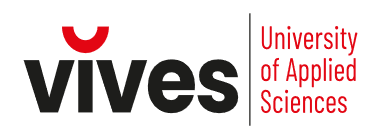<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **POLYNOMIAL REGRESSION AND OVERFITTING: INTRODUCTION**

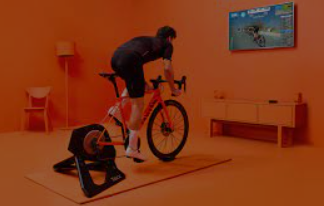

## **The Dataset**

Import statements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Read dataset

In [2]:
df = pd.read_csv("zwift2.csv")
df.head()

,time (min),distance (km)
0,0,0.00
1,1,0.92
2,2,0.37
3,3,1.30
4,4,2.12


Explore dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time (min)     61 non-null     int64  
 1   distance (km)  61 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time (min),61.0,30.000000,17.752934,0.0,15.00,30.00,45.00,60.00
distance (km),61.0,14.081803,7.644994,0.0,7.39,14.43,21.45,25.49


Plot dataset

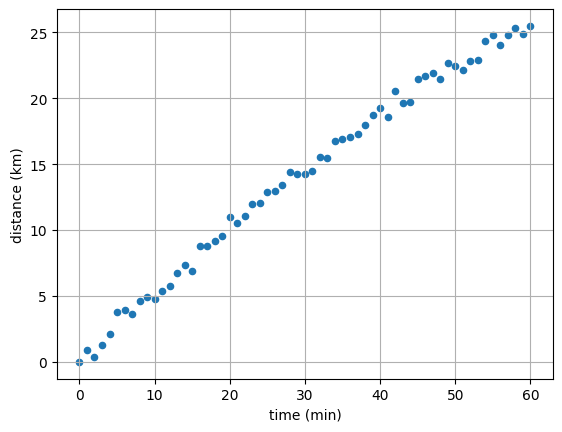

In [5]:
xcol, ycol = tuple(df.columns)
df.plot.scatter(x=xcol, y=ycol, grid=True);

## **Simple Linear Regression**

Function to calculate mean absolute error

In [6]:
MAE = lambda y, y_fit: np.mean(np.abs(y - y_fit))

Linear regression using `np.linalg.lstsq()` (= method of least squares)

0.6153692295688811


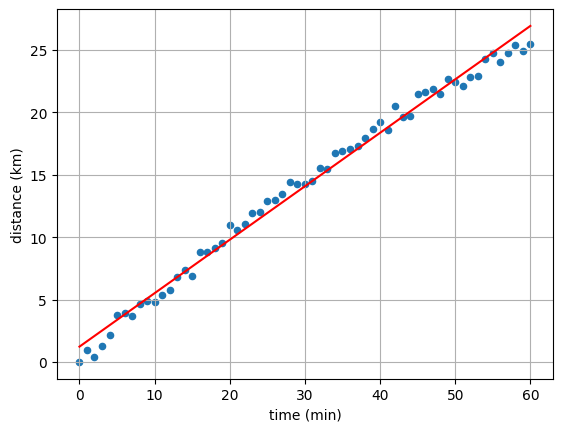

In [7]:
x, y = df[[xcol]].values, df[[ycol]].values
X = np.hstack([x, np.ones_like(x)]) # Add a column of ones for the intercept

coef = np.linalg.lstsq(X, y, rcond=None)
y_fit = X @ coef[0]

df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Linear regression using `np.polyfit()` (degree 1)

0.6153692295688812


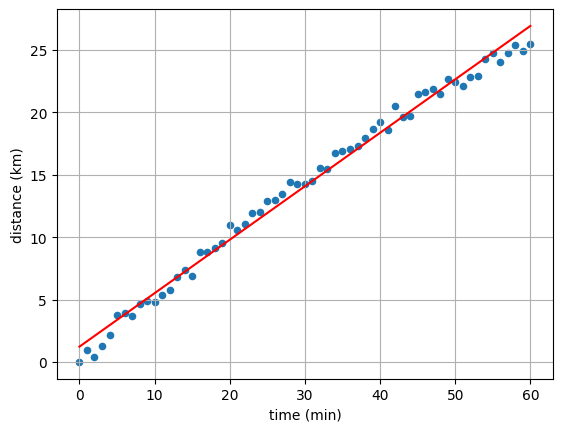

In [8]:
x, y = df[xcol].values, df[ycol].values
coef = np.polyfit(x, y, deg=1)
y_fit = np.polyval(coef, x)
df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Linear regression using sklearn `LinearRegression`

In [9]:
from sklearn.linear_model import LinearRegression

X, y = df[[xcol]].values, df[ycol].values

lr = LinearRegression()
lr.fit(X, y)
print(lr.score(X, y))  # R²

0.990365249649032


0.6153692295688812


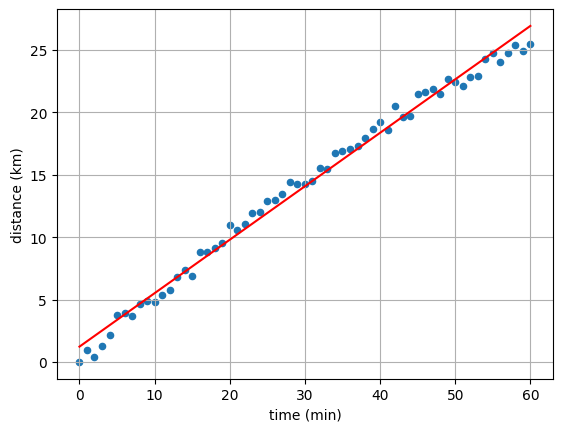

In [10]:
y_fit = lr.predict(X)
df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

## **Polynomial Regression**

Polynomial regression using `np.linalg.lstsq()` (degree 2)

0.36648007367931346


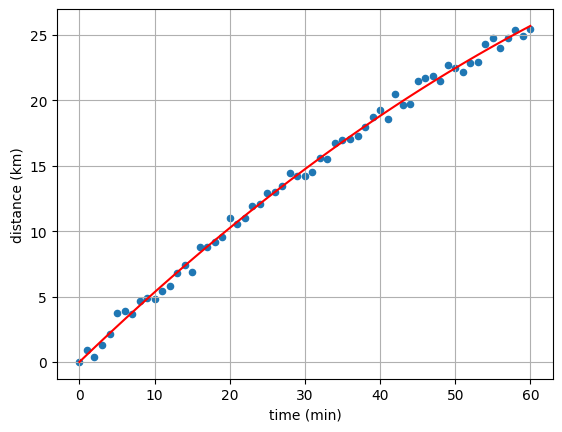

In [11]:
X1, y = df[[xcol]].values, df[[ycol]].values
X2 = X1**2
X = np.hstack((X1, X2))  # X = [X1, X2]

coef = np.linalg.lstsq(X, y, rcond=None)
y_fit = X @ coef[0]

df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Polynomial regression using `np.polyfit()` (degree 2)

0.3666305961656603


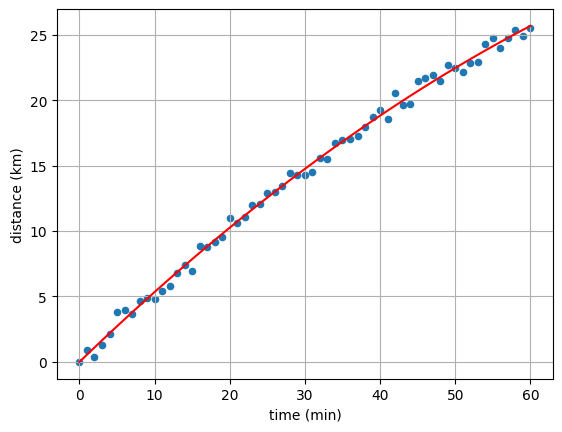

In [12]:
x, y = df[xcol].values, df[ycol].values
coef = np.polyfit(x, y, deg=2)
y_fit = np.polyval(coef, x)
df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Polynomial regression using sklearn `LinearRegression` (degree 2)

In [13]:
lr = LinearRegression()
lr.fit(X, y)  # X = [X1, X2]
print(lr.score(X, y))

0.996416356745475


0.3666305961656604


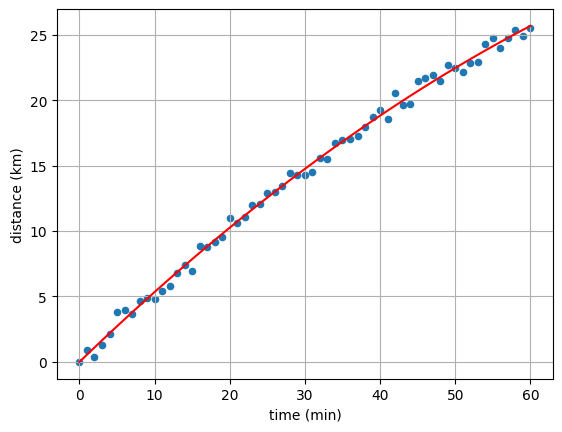

In [14]:
y_fit = lr.predict(X)
df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Polynomial regression using `PolynomialFeatures` (degree 2)

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X = poly.fit_transform(X1)
lr = LinearRegression()
lr.fit(X, y)
lr.score(X, y)

0.996416356745475

Polynomial regression using `PolynomialFeatures` (degree 2) and `make_pipeline()`

In [16]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                      LinearRegression())
model.fit(X1, y)
model.score(X1, y)

0.996416356745475

**Note: the fitted models use an intercept, although physically a zero intercept would make more sense!**

## **Finding the Best Degree**

Polynomial regression using `np.polyfit()` (degree 3)

0.36490473950603053


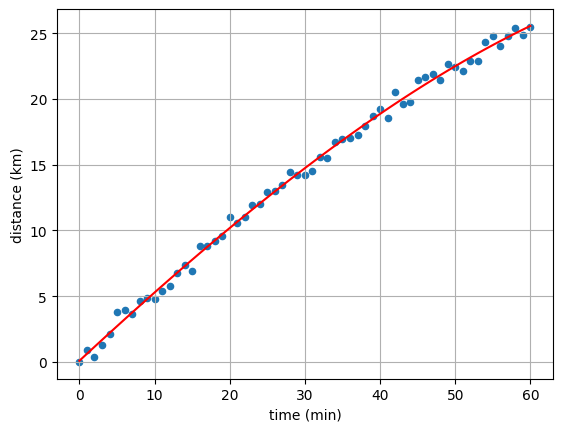

In [17]:
x, y = df[xcol].values, df[ycol].values
coef = np.polyfit(x, y, deg=3)
y_fit = np.polyval(coef, x)
df.plot.scatter(x=xcol, y=ycol, grid=True)
plt.plot(x, y_fit, 'r-');
print(MAE(y, y_fit))

Slightly smaller MAE... But is degree 3 indeed better?

Finding the best degree by applying **simple hold-out validation**

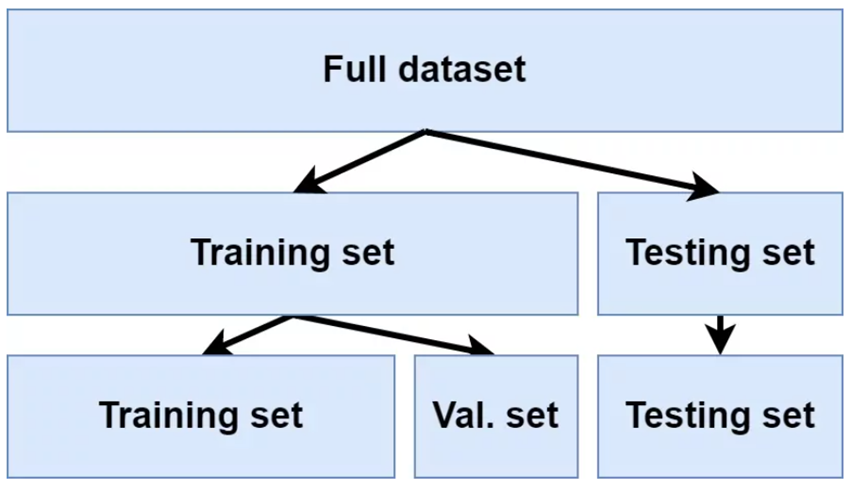

Split dataset: 50% training and 50% validation

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X1, y, test_size=0.5, random_state=42)

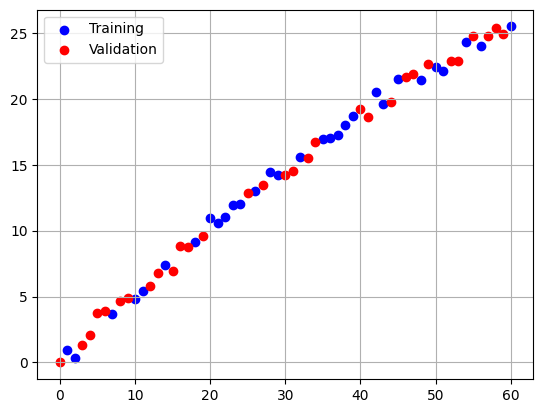

In [19]:
plt.scatter(X_train, y_train, color='b', label="Training")
plt.scatter(X_val, y_val, color='r', label="Validation")
plt.grid();
plt.legend();

Construct **model complexity graph**

In [20]:
degrees = range(1, 7)  # degrees range from 1 to 6
r2_scores_train, r2_scores_val = [], []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)
    r2_scores_train.append(model.score(X_train, y_train))
    r2_scores_val.append(model.score(X_val, y_val))

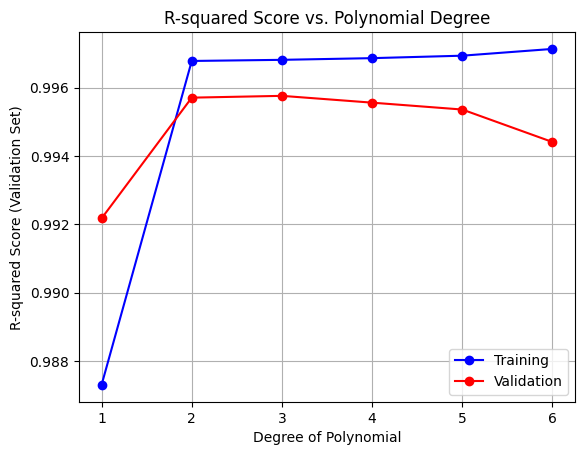

In [21]:
plt.plot(degrees, r2_scores_train, 'bo-', label="Training");
plt.plot(degrees, r2_scores_val, 'ro-', label="Validation");
plt.legend()
plt.xlabel('Degree of Polynomial')
plt.ylabel('R-squared Score (Validation Set)')
plt.title('R-squared Score vs. Polynomial Degree')
plt.grid();

In [22]:
best_degree = degrees[np.argmax(r2_scores_val)]
print(f"The best degree for the polynomial regression is: {best_degree}")

The best degree for the polynomial regression is: 3


Because it is a small dataset, it's better to apply **cross-validation**

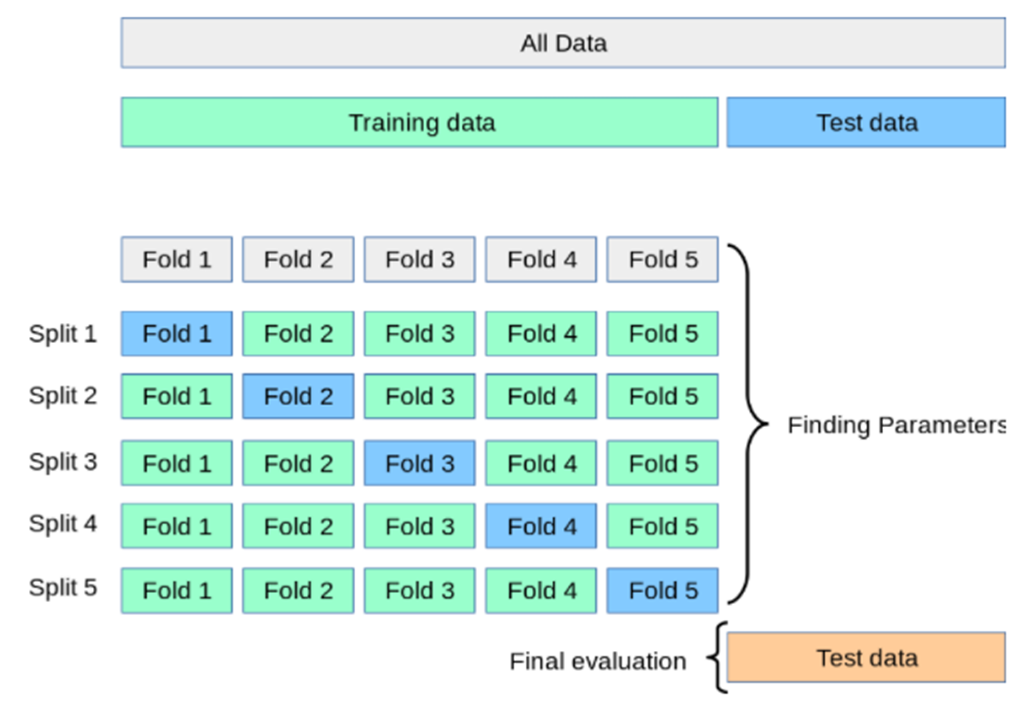

In [23]:
from sklearn.model_selection import KFold

degrees = range(1, 8)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_train_cv = []
r2_scores_val_cv = []

for degree in degrees:

    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())

    train_scores_per_fold = []
    val_scores_per_fold = []

    for train_index, val_index in kf.split(X1, y):
        X_train, X_val = X1[train_index], X1[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        train_scores_per_fold.append(model.score(X_train, y_train))
        val_scores_per_fold.append(model.score(X_val, y_val))

    r2_scores_train_cv.append(np.mean(train_scores_per_fold))
    r2_scores_val_cv.append(np.mean(val_scores_per_fold))

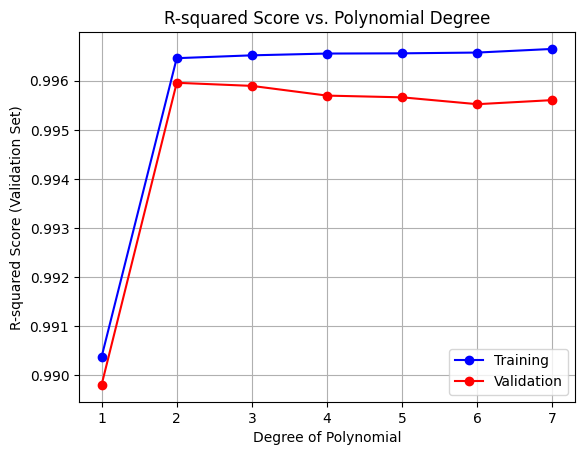

In [24]:
plt.plot(degrees, r2_scores_train_cv, 'bo-', label="Training");
plt.plot(degrees, r2_scores_val_cv, 'ro-', label="Validation");
plt.legend()
plt.xlabel('Degree of Polynomial')
plt.ylabel('R-squared Score (Validation Set)')
plt.title('R-squared Score vs. Polynomial Degree')
plt.grid();

In [25]:
best_degree_cv = degrees[np.argmax(r2_scores_val_cv)]
print(f"The best degree for the polynomial regression using cross-validation is: {best_degree_cv}")

The best degree for the polynomial regression using cross-validation is: 2


Finding the best degree by applying cross-validation and grid search

In [26]:
from sklearn.model_selection import GridSearchCV

model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
param_grid = {'polynomialfeatures__degree': np.arange(1, 8)}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=kf)

grid_search.fit(X1, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures(degree=7,
                                                           include_bias=False)),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'polynomialfeatures__degree': array([1, 2, 3, 4, 5, 6, 7])})

In [27]:
print(f"Best polynomial degree: {grid_search.best_params_['polynomialfeatures__degree']}")
print(f"Best R-squared score: {grid_search.best_score_}")

Best polynomial degree: 2
Best R-squared score: 0.9959580856347741


**Note: it's best practice to also use a test set for the final evaluation!**

---